# Analisis Polutan Atmosfer di Kabupaten Sidoarjo Berdasarkan Citra Satelit Sentinel-5P

## Business Understanding

Kualitas udara adalah salah satu penentu kesehatan masyarakat. Notebook ini bertujuan memahami bagaimana konsentrasi beberapa polutan udara berubah sepanjang satu tahun terakhir di Kabupaten Sidoarjo, Jawa Timur — sebuah wilayah yang padat aktivitas industri dan lalu lintas.

Alih-alih mengandalkan stasiun pemantauan di darat, kita memanfaatkan data satelit **Sentinel-5P TROPOMI** dari Copernicus Data Space Ecosystem. Satelit ini mengukur gas-gas polutan di atmosfer dari orbit, sehingga kita bisa mendapatkan gambaran kualitas udara di atas seluruh wilayah kabupaten.

Polutan yang dianalisis cukup beragam, dan masing-masing punya cerita sendiri:

- **NO₂ (Nitrogen Dioxide)** adalah gas yang terutama keluar dari knalpot kendaraan dan cerobong pabrik. Semakin ramai lalu lintas dan industri, semakin tinggi NO₂.
- **CO (Carbon Monoxide)** muncul dari pembakaran tidak sempurna bahan bakar, misalnya mesin kendaraan atau pembakaran biomassa.
- **HCHO (Formaldehida)** adalah indikator senyawa organik yang banyak dilepaskan industri maupun vegetasi, dan sering disebut sebagai "benih" pembentuk polusi udara lain.
- **SO₂ (Sulfur Dioxide)** umumnya berasal dari pembakaran bahan bakar yang mengandung belerang di industri dan pembangkit listrik.
- **O₃ (Ozon)** di permukaan tanah bukanlah ozon pelindung di langit, melainkan polutan yang terbentuk ketika sinar matahari bereaksi dengan gas-gas lain — biasanya meningkat saat cuaca cerah.

Alur kerja notebook ini sederhana: siapkan batas wilayah Sidoarjo → ambil data satelit satu tahun terakhir untuk tiap polutan → rapikan dan gabungkan datanya → visualisasikan trennya → simpan hasilnya. Mari kita mulai.

### Unduh Data Analisis



Semua file di bawah ini tersimpan di folder `data/downloads/`. Klik tombol untuk mengunduh.



**Batas wilayah**



- **sidoarjo.geojson** — batas administrasi Kabupaten Sidoarjo dalam format GeoJSON; dipakai sebagai area of interest saat mengambil data satelit.



<a href="data/downloads/sidoarjo.geojson" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; Unduh sidoarjo.geojson</a>



**Hasil pengukuran satelit per polutan** — masing-masing berisi deret waktu harian satu kolom tanggal dan satu kolom konsentrasi polutan (mol/m²) hasil rata-rata spasial di seluruh Sidoarjo:



- **sidoarjo_NO2.csv** — Nitrogen Dioxide — indikator emisi kendaraan dan industri.

- **sidoarjo_CO.csv** — Carbon Monoxide — hasil pembakaran tidak sempurna bahan bakar.

- **sidoarjo_HCHO.csv** — Formaldehyde — penanda senyawa organik volatil (VOC).

- **sidoarjo_SO2.csv** — Sulfur Dioxide — emisi industri/pembangkit listrik.

- **sidoarjo_O3.csv** — Ozon permukaan — polutan sekunder yang terbentuk oleh sinar matahari.



<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_NO2.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_NO2.csv</a>

<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_CO.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_CO.csv</a>

<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_HCHO.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_HCHO.csv</a>

<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_SO2.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_SO2.csv</a>

<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_O3.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_O3.csv</a>



**Data gabungan & versi tren**



- **sidoarjo_pollutants.csv** — kelima polutan digabung dalam satu tabel dengan indeks tanggal yang sama (data harian mentah).

- **sidoarjo_pollutants_rolling30.csv** — versi rolling mean 30 hari dari tabel gabungan; kurvanya lebih halus sehingga tren jangka panjang lebih mudah dibaca.



<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_pollutants.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_pollutants.csv</a>

<a href="data/downloads/sidoarjo_pollutants_data/sidoarjo_pollutants_rolling30.csv" download
   style="display:inline-block;padding:8px 18px;margin:4px 6px 4px 0;background:#1a73e8;color:#ffffff;text-decoration:none;border-radius:8px;font-weight:bold;font-size:14px;">&#11015;&#65039; sidoarjo_pollutants_rolling30.csv</a>


In [ ]:
!pip install openeo
import openeo
import json
import pandas as pd
import numpy as np
import os
import sys

Kita mulai dengan menyiapkan "peralatan dapur". Library `openeo` dipasang dan diimpor agar bisa berkomunikasi dengan layanan data Copernicus, sementara `pandas`, `numpy`, `json`, `os`, dan `sys` akan membantu pengolahan tabel, angka, dan file di sepanjang analisis.

In [2]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=DYVV-DOYB 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Setelah semua alat siap, kita membuka "gerbang" menuju gudang data satelit Copernicus. Fungsi `connect` membuat koneksi ke server openEO, dan `authenticate_oidc()` mengautentikasi identitas kita — biasanya lewat tautan login yang muncul di output. Setelah langkah ini berhasil, kita berhak mengunduh data Sentinel-5P.

In [3]:
GEOJSON_PATH = "sidoarjo.geojson"

if not os.path.exists(GEOJSON_PATH):
    if "google.colab" in sys.modules:
        from google.colab import files
        print("File 'sidoarjo.geojson' tidak ditemukan di sesi ini. Silakan upload:")
        uploaded = files.upload()
        # Jika nama file hasil upload berbeda, ubah namanya menjadi sidoarjo.geojson
        uploaded_name = list(uploaded.keys())[0]
        if uploaded_name != GEOJSON_PATH:
            os.rename(uploaded_name, GEOJSON_PATH)
    else:
        raise FileNotFoundError(
            f"'{GEOJSON_PATH}' tidak ditemukan. Letakkan file ini di direktori kerja sebelum lanjut."
        )

print(f"Menggunakan file AOI: {GEOJSON_PATH}")

File 'sidoarjo.geojson' tidak ditemukan di sesi ini. Silakan upload:


Saving sidoarjo.geojson to sidoarjo.geojson
Menggunakan file AOI: sidoarjo.geojson


Sebelum mengambil data satelit, kita butuh "kertas peta" berisi batas administrasi Kabupaten Sidoarjo dalam format GeoJSON (`sidoarjo.geojson`). Kode ini memastikan file tersebut tersedia: kalau belum ada dan kita sedang berjalan di Google Colab, pengguna diminta mengunggahnya; nama file hasil unggahan dirapikan menjadi `sidoarjo.geojson`. Kalau file tetap tidak ditemukan di lingkungan lain, proses dihentikan dengan pesan yang jelas.

In [4]:
import shapely.geometry

# Baca file GeoJSON berisi batas wilayah Kabupaten Sidoarjo
with open(GEOJSON_PATH, 'r') as f:
    geojson_data = json.load(f)

feature = geojson_data['features'][0]
geometry = feature['geometry']

# Ubah GeoJSON menjadi objek geometri shapely untuk seluruh wilayah kabupaten
shp = shapely.geometry.shape(geometry)
print(f"Geometry type: {shp.geom_type}")
if shp.geom_type == 'MultiPolygon':
    print(f"Jumlah bagian polygon: {len(shp.geoms)}")
    for i, part in enumerate(shp.geoms):
        pw, ps, pe, pn = part.bounds
        print(f"  bagian {i}: bbox approx {(pe-pw)*111:.2f} km x {(pn-ps)*111:.2f} km, {len(part.exterior.coords)} vertices")

# Gunakan geometri lengkap sebagai area of interest (AOI)
aoi = geometry

# Hitung bounding box dari keseluruhan geometri kabupaten
west, south, east, north = shp.bounds
spatial_extent = {
    "west": west,
    "south": south,
    "east": east,
    "north": north,
}

print(f"\nAOI defined for Sidoarjo region")
print(f"Bounding box: {spatial_extent}")
print(f"Bounding box size (approx): {(east-west)*111:.1f} km x {(north-south)*111:.1f} km")

Geometry type: MultiPolygon
Jumlah bagian polygon: 2
  bagian 0: bbox approx 1.52 km x 1.64 km, 84 vertices
  bagian 1: bbox approx 46.99 km x 27.44 km, 2184 vertices

AOI defined for Sidoarjo region
Bounding box: {'west': 112.4566879, 'south': -7.5781187, 'east': 112.8834192, 'north': -7.3302067}
Bounding box size (approx): 47.4 km x 27.5 km


File GeoJSON kemudian dibaca dan diubah menjadi objek geometri menggunakan `shapely`, sehingga kita bisa memeriksa bentuk wilayahnya (misalnya apakah berupa MultiPolygon) serta menghitung bounding box — kotak pembatas utara-selatan-timur-barat yang mencakup seluruh Kabupaten Sidoarjo. Kotak inilah yang nantinya memberi tahu satelit area mana yang harus diamati.

In [5]:
pollutant_bands = ["NO2", "CO", "HCHO", "SO2", "O3"]
time_extent = ["2025-08-24", "2026-08-24"]

def build_pollutant_cube(band):
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=time_extent,
        spatial_extent=spatial_extent,
        bands=[band],
    )
    # Rata-ratakan nilai per hari agar setiap tanggal hanya punya satu nilai
    cube = cube.aggregate_temporal_period(reducer="mean", period="day")
    # Hitung rata-rata spasial di seluruh wilayah sehingga menjadi deret waktu harian
    cube = cube.aggregate_spatial(reducer="mean", geometries=aoi)
    return cube

print(f"Akan membuat {len(pollutant_bands)} job terpisah, satu per polutan: {pollutant_bands}")

Akan membuat 5 job terpisah, satu per polutan: ['NO2', 'CO', 'HCHO', 'SO2', 'O3']


Sekarang saatnya menyusun "pesanan" data. Untuk setiap polutan (NO2, CO, HCHO, SO2, O3), fungsi `build_pollutant_cube` memuat koleksi Sentinel-5P L2 pada rentang waktu satu tahun dan area Sidoarjo. Nilai mentahnya lalu dirata-ratakan per hari, kemudian dirata-ratakan lagi secara spasial di atas geometri kabupaten — hasil akhirnya adalah deret waktu harian: satu angka konsentrasi per tanggal per polutan.

In [6]:
output_files = {}

for band in pollutant_bands:
    print(f"\n=== Menjalankan job untuk band: {band} ===")
    cube = build_pollutant_cube(band)
    outputfile = f"sidoarjo_{band}.csv"
    # Simpan hasil dalam format CSV
    job = cube.execute_batch(title=f"Polutan Sidoarjo - {band}", outputfile=outputfile, out_format="CSV")
    output_files[band] = outputfile
    print(f"Selesai: {outputfile}")

print("\nSemua job selesai. File output:", output_files)


=== Menjalankan job untuk band: NO2 ===
0:00:00 Job 'j-26082411520047438db3ccb0fb81c9f7': send 'start'
0:00:03 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:00:08 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:00:15 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:00:23 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:00:34 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:00:46 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:01:02 Job 'j-26082411520047438db3ccb0fb81c9f7': queued (progress 0%)
0:01:22 Job 'j-26082411520047438db3ccb0fb81c9f7': running (progress N/A)
0:01:46 Job 'j-26082411520047438db3ccb0fb81c9f7': running (progress N/A)
0:02:17 Job 'j-26082411520047438db3ccb0fb81c9f7': running (progress N/A)
0:02:54 Job 'j-26082411520047438db3ccb0fb81c9f7': running (progress N/A)
0:03:41 Job 'j-26082411520047438db3ccb0fb81c9f7': running (progress N/A)
0:04:40 Job 'j-26082411520047438db

Pesanan yang sudah disusun dikirim ke server untuk dihitung. Loop ini menjalankan satu batch job per polutan, menunggunya sampai selesai (progresnya terlihat di output), lalu mengunduh hasilnya sebagai file CSV — misalnya `sidoarjo_NO2.csv`. Setelah loop selesai, kelima polutan sudah tersimpan rapi di lima file CSV.

In [7]:
import matplotlib.pyplot as plt

Untuk tahap visualisasi, kita mengimpor `matplotlib.pyplot` — library standar Python untuk menggambar grafik.

In [8]:
series_by_pollutant = {}

for band, path in output_files.items():
    df = pd.read_csv(path)
    print(f"{band}: kolom = {list(df.columns)}")

    # Cari kolom yang berisi tanggal/waktu
    time_col_candidates = [c for c in df.columns if c.lower() in ("date", "time", "t", "datetime")]
    time_col = time_col_candidates[0] if time_col_candidates else df.columns[0]

    # Tentukan kolom yang berisi nilai konsentrasi polutan
    exclude_cols = {time_col, "feature_index", "geometry"}
    if band in df.columns:
        value_col = band
    else:
        numeric_candidates = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
        value_col = numeric_candidates[0]

    times = pd.to_datetime(df[time_col])
    series_by_pollutant[band] = pd.Series(df[value_col].values, index=times, name=band)
    print(f"  -> {len(times)} titik waktu, kolom waktu='{time_col}', kolom nilai='{value_col}'")

# Gabungkan kelima polutan menjadi satu tabel berdasarkan tanggal
combined = pd.concat(series_by_pollutant.values(), axis=1).sort_index()
combined.index.name = "date"
combined.head()

NO2: kolom = ['date', 'feature_index', 'NO2']
  -> 366 titik waktu, kolom waktu='date', kolom nilai='NO2'
CO: kolom = ['date', 'feature_index', 'CO']
  -> 366 titik waktu, kolom waktu='date', kolom nilai='CO'
HCHO: kolom = ['date', 'feature_index', 'HCHO']
  -> 366 titik waktu, kolom waktu='date', kolom nilai='HCHO'
SO2: kolom = ['date', 'feature_index', 'SO2']
  -> 366 titik waktu, kolom waktu='date', kolom nilai='SO2'
O3: kolom = ['date', 'feature_index', 'O3']
  -> 366 titik waktu, kolom waktu='date', kolom nilai='O3'


,NO2,CO,HCHO,SO2,O3
date,,,,,
2025-08-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2025-08-24 00:00:00+00:00,0.000040,0.035788,0.000217,0.000287,0.116273
2025-08-25 00:00:00+00:00,0.000049,0.032255,0.000243,0.000562,0.116746
2025-08-26 00:00:00+00:00,0.000060,0.035359,0.000233,0.000136,0.115952
2025-08-27 00:00:00+00:00,0.000043,0.035639,0.000219,0.000272,0.116067


Lima file CSV dari struktur kolom yang mungkin berbeda-beda kini dibaca satu per satu. Kode ini otomatis mengenali kolom mana yang berisi tanggal dan kolom mana yang berisi nilai konsentrasi, lalu mengubahnya menjadi deret waktu pandas. Terakhir, kelima deret tersebut digabung menjadi satu tabel `combined` dengan indeks tanggal yang sama — sehingga sekilas kita sudah bisa melihat angka harian semua polutan berdampingan.

In [9]:
rolling = combined.rolling(window=30, min_periods=1).mean()
rolling.head()

,NO2,CO,HCHO,SO2,O3
date,,,,,
2025-08-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2025-08-24 00:00:00+00:00,0.000040,0.035788,0.000217,0.000287,0.116273
2025-08-25 00:00:00+00:00,0.000045,0.034022,0.000230,0.000424,0.116509
2025-08-26 00:00:00+00:00,0.000050,0.034468,0.000231,0.000328,0.116324
2025-08-27 00:00:00+00:00,0.000048,0.034760,0.000228,0.000314,0.116259


Data harian asli cenderung "bergerigi" karena fluktuasi harian. Di sinilah rolling mean 30 hari berperan: setiap titik diganti dengan rata-rata 30 hari terakhirnya. Hasilnya, `rolling`, adalah versi kurva yang lebih halus sehingga tren jangka panjang tiap polutan lebih mudah terbaca.

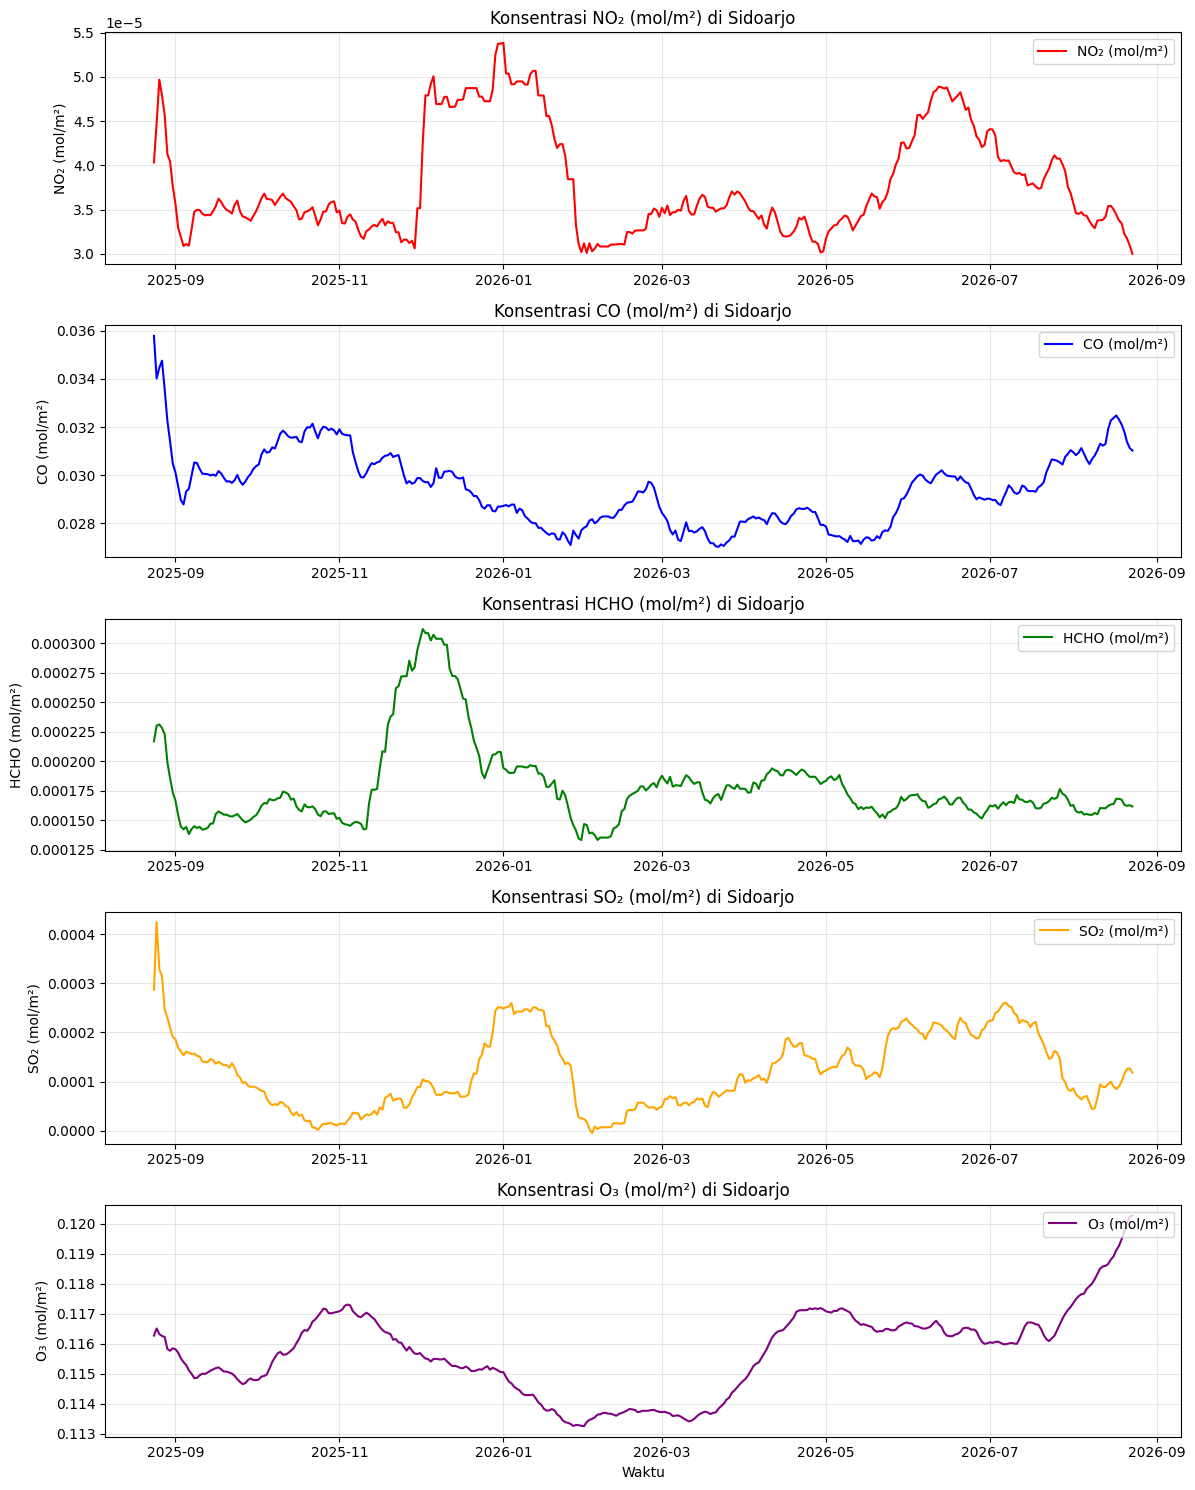

In [10]:
# Gambar grafik garis tren waktu untuk masing-masing polutan
pollutant_labels = {
    'NO2': 'NO₂ (mol/m²)',
    'CO': 'CO (mol/m²)',
    'HCHO': 'HCHO (mol/m²)',
    'SO2': 'SO₂ (mol/m²)',
    'O3': 'O₃ (mol/m²)',
}
colors = {'NO2': 'red', 'CO': 'blue', 'HCHO': 'green', 'SO2': 'orange', 'O3': 'purple'}

fig, axes = plt.subplots(len(pollutant_bands), 1, figsize=(12, 15), dpi=100)

for i, band in enumerate(pollutant_bands):
    if band in rolling.columns:
        label = pollutant_labels.get(band, band)
        axes[i].plot(rolling.index, rolling[band], color=colors.get(band, 'black'), label=label)
        axes[i].set_ylabel(label)
        axes[i].set_title(f'Konsentrasi {label} di Sidoarjo')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Waktu')
plt.tight_layout()
plt.show()

Inilah momen utamanya: kelima polutan digambar sebagai grafik garis dalam panel terpisah, masing-masing dengan warna dan label satuan sendiri. Dari sini kita dapat mengamati naik-turunnya konsentrasi sepanjang tahun — pola yang akan kita interpretasikan di bagian akhir notebook.

In [11]:
# Simpan data gabungan dan versi rolling mean ke file CSV
combined.reset_index().to_csv('sidoarjo_pollutants.csv', index=False)
rolling.reset_index().to_csv('sidoarjo_pollutants_rolling30.csv', index=False)
print('Data disimpan ke sidoarjo_pollutants.csv dan sidoarjo_pollutants_rolling30.csv')
print(f'Data shape: {combined.shape}')
print('\nFirst few rows:')
combined.head()

Data disimpan ke sidoarjo_pollutants.csv dan sidoarjo_pollutants_rolling30.csv
Data shape: (366, 5)

First few rows:


,NO2,CO,HCHO,SO2,O3
date,,,,,
2025-08-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2025-08-24 00:00:00+00:00,0.000040,0.035788,0.000217,0.000287,0.116273
2025-08-25 00:00:00+00:00,0.000049,0.032255,0.000243,0.000562,0.116746
2025-08-26 00:00:00+00:00,0.000060,0.035359,0.000233,0.000136,0.115952
2025-08-27 00:00:00+00:00,0.000043,0.035639,0.000219,0.000272,0.116067


Agar hasil analisis tidak hilang, dua versi data disimpan sebagai CSV: tabel gabungan harian (`sidoarjo_pollutants.csv`) dan versi rolling mean 30 hari (`sidoarjo_pollutants_rolling30.csv`). Beberapa baris pertama ditampilkan sebagai pemeriksaan cepat bahwa isinya masuk akal.

In [12]:
import zipfile

output_zip_filename = 'sidoarjo_pollutants_data.zip'
csv_files_to_zip = [
    'sidoarjo_NO2.csv',
    'sidoarjo_CO.csv',
    'sidoarjo_HCHO.csv',
    'sidoarjo_SO2.csv',
    'sidoarjo_O3.csv',
    'sidoarjo_pollutants.csv',
    'sidoarjo_pollutants_rolling30.csv'
]

with zipfile.ZipFile(output_zip_filename, 'w') as zipf:
    for csv_file in csv_files_to_zip:
        if os.path.exists(csv_file):
            zipf.write(csv_file, os.path.basename(csv_file))
            print(f'Menambahkan {csv_file} ke {output_zip_filename}')
        else:
            print(f'Peringatan: {csv_file} tidak ditemukan dan tidak akan ditambahkan ke ZIP.')

print(f'Semua file CSV berhasil di-ZIP ke: {output_zip_filename}')

# Jika berjalan di Google Colab, unduh file ZIP secara otomatis
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(output_zip_filename)


Menambahkan sidoarjo_NO2.csv ke sidoarjo_pollutants_data.zip
Menambahkan sidoarjo_CO.csv ke sidoarjo_pollutants_data.zip
Menambahkan sidoarjo_HCHO.csv ke sidoarjo_pollutants_data.zip
Menambahkan sidoarjo_SO2.csv ke sidoarjo_pollutants_data.zip
Menambahkan sidoarjo_O3.csv ke sidoarjo_pollutants_data.zip
Menambahkan sidoarjo_pollutants.csv ke sidoarjo_pollutants_data.zip
Menambahkan sidoarjo_pollutants_rolling30.csv ke sidoarjo_pollutants_data.zip
Semua file CSV berhasil di-ZIP ke: sidoarjo_pollutants_data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Terakhir, semua file CSV hasil analisis dikemas ke dalam satu arsip ZIP (`sidoarjo_pollutants_data.zip`) supaya mudah diunduh sekaligus. Jika notebook dijalankan di Colab, unduhan bahkan dimulai otomatis.

## Analisis dan Interpretasi

Melihat kelima grafik di atas, ada beberapa cerita yang menonjol. Konsentrasi **NO₂** bergerak naik-turun sepanjang tahun dengan lonjakan pada periode tertentu — pola yang wajar untuk wilayah padat kendaraan seperti Sidoarjo, karena NO₂ sangat berkaitan dengan intensitas lalu lintas dan industri. **CO** menunjukkan tren yang relatif stabil dengan fluktuasi ringan, mengikuti aktivitas pembakaran bahan bakar sehari-hari. Kurva **O₃** tampak lebih tinggi pada bulan-bulan cerah, sesuai sifatnya yang terbentuk dengan bantuan sinar matahari. Sementara itu, **HCHO** dan **SO₂** berada pada level yang rendah namun tetap berfluktuasi, dengan SO₂ sesekali mengalami lonjakan singkat yang bisa berkaitan dengan aktivitas industri tertentu.

Perlu diingat bahwa garis yang kita lihat adalah hasil smoothing rolling mean 30 hari — jadi yang terbaca adalah gelombang tren jangka panjang, bukan kejadian harian.

## Kesimpulan

Analisis ini menunjukkan bahwa citra satelit Sentinel-5P dapat memberi gambaran kualitas udara Kabupaten Sidoarjo selama satu tahun penuh tanpa perlu stasiun pemantauan tambahan. Dari alur business understanding hingga visualisasi, kita berhasil mengubah ribuan pengamatan satelit menjadi lima kurva tren yang mudah dibaca.

Langkah lanjutan yang bisa dilakukan antara lain: membandingkan dengan tahun-tahun sebelumnya, menguji korelasi antar polutan (misalnya apakah O₃ naik saat NO₂ turun), atau memetakan distribusi spasial di dalam kabupaten untuk menemukan titik-titik sumber emisi. Data yang sudah tersimpan dalam ZIP siap dipakai untuk analisis lanjutan tersebut.